
# **Dataset UKgas**
O conjunto de dados **UKgas** é um clássico no estudo de séries temporais, frequentemente utilizado para demonstrar a análise de componentes como tendência e sazonalidade trimestral, com um padrão sazonal particularmente interessante e didático.

## **Visão Geral do Dataset UKgas**

* **Conteúdo**	Consumo trimestral de gás no Reino Unido (em milhões de termas).
* **Período**	Do primeiro trimestre de 1960 ao quarto trimestre de 1986 .
* **Frequência** 	Trimestral (4 observações por ano).
* **Número de Observações**	108 observações (27 anos × 4 trimestres).

* **Tendência de Crescimento** Ao longo dos 27 anos, há uma clara tendência de crescimento no consumo de gás, refletindo a expansão do uso de gás natural no Reino Unido durante as décadas de 1960, 1970 e 1980.

* **Sazonalidade Trimestral com Padrão de "Onda"**
O padrão sazonal é o grande destaque deste dataset. O consumo de gás é significativamente maior no inverno (primeiro e quarto trimestres) e menor no verão (terceiro trimestre), devido à necessidade de aquecimento residencial e comercial. Isso cria um padrão em forma de "onda" ou "serra" que é facilmente identificável visualmente.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.pylab import rcParams
from statsmodels.tsa.statespace.sarimax import SARIMAX

rcParams['figure.figsize'] = 15, 7

# Carregar o dataset
ukgas_data = sm.datasets.get_rdataset('UKgas')
df = ukgas_data.data



In [2]:
# O dataset UKgas é trimestral (1960 Q1 até 1986 Q4)
# Criar índice temporal trimestral corretamente
serie_gas = pd.Series(
    df['value'].values,
    index=pd.date_range(start='1960-01-01', periods=len(df), freq='QS')
)

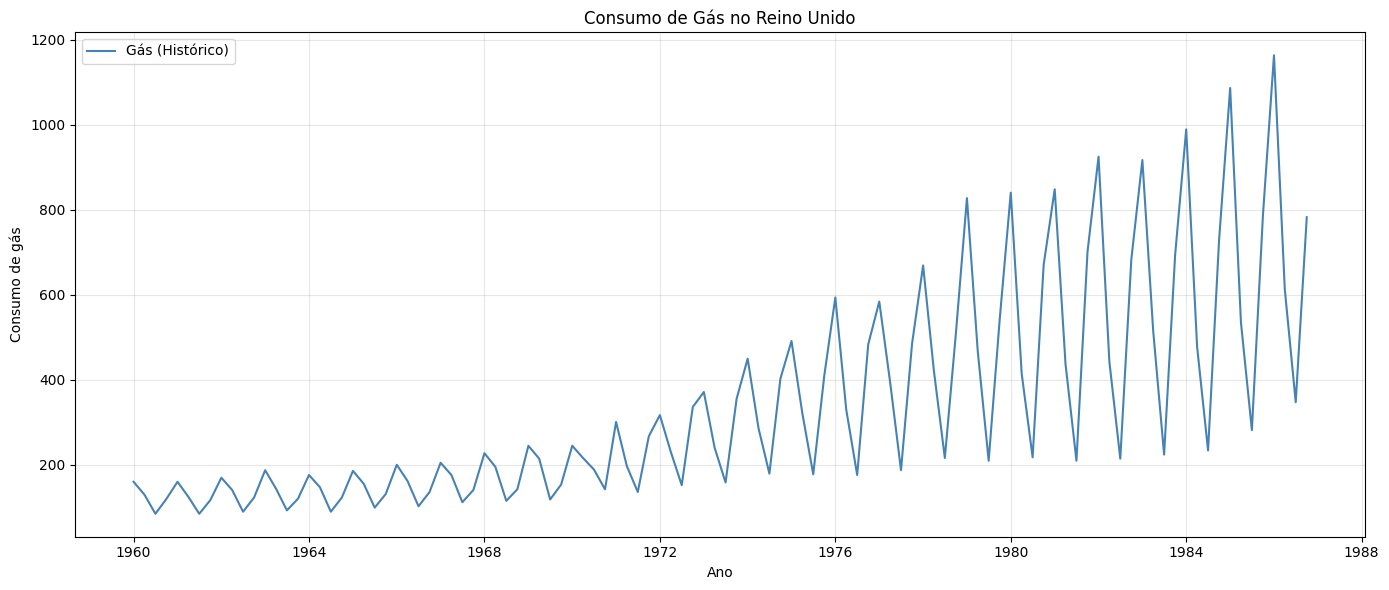

In [3]:
# Gráfico
plt.figure(figsize=(14, 6))
plt.plot(serie_gas, label='Gás (Histórico)', color='steelblue')
plt.title('Consumo de Gás no Reino Unido')
plt.xlabel('Ano')
plt.ylabel('Consumo de gás')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# **Modelo SARIMAX**


**SARIMAX** significa Seasonal AutoRegressive Integrated Moving Average with eXogenous variables. É uma extensão do modelo ARIMA que incorpora dois componentes adicionais: **sazonalidade (S) e variáveis exógenas (X).**


## **Composição do modelo.**

Sigla	Significado	Função
* **S:**	Seasonal	Captura padrões que se repetem em ciclos
* **AR:**	AutoRegressive	Usa valores passados da própria série
* **I:**	Integrated	Diferenciação para tornar a série estacionária
* **MA:**	Moving Average	Usa erros passados de previsão
* **X:** eXogenous	Variáveis externas que influenciam a série
A notação típica é: SARIMAX(p, d, q)(P, D, Q)[s]

Sendo:

##  **Componentes Não Sazonais $(p, d, q)$**
 * **$p$ (Ordem AR):** Número de lags do passado usados para prever o presente.
 * **$d$ (Grau de Diferenciação):** Quantas vezes a série precisa ser diferenciada para ficar estacionária.

 * **$q$ (Ordem MA):** Número de erros de previsão passados incluídos no modelo.

##  **Componentes Sazonais $(P, D, Q)_s$**
  
  * **$P$ (Ordem AR Sazonal):** Relação entre o período atual e o mesmo período no ciclo passado (ex.: este mês vs. mesmo mês do ano passado).
  * **$D$ (Diferenciação Sazonal):** Subtração entre o período atual e o período correspondente da sazonalidade anterior.
  * **$Q$ (Ordem MA Sazonal):** Erros residuais sazonais passados.$s$ (Período Sazonal): O número de passos por ciclo (ex.: $s = 12$ para dados mensais com sazonalidade anual, $s = 7$ para dados diários com sazonalidade semanal).


# **2. Componentes do Modelo**

## **a) Componente Autorregressivo (AR)**

O valor atual da série depende dos seus valores passados:

$$
y_t = c + \sum_{i=1}^{p} \phi_i \, y_{t-i} + \varepsilon_t
$$

onde $\phi_1, \phi_2, \dots, \phi_p$ são os coeficientes autorregressivos, $c$ é uma constante e $\varepsilon_t \sim \mathcal{N}(0, \sigma^2)$ é o ruído branco.



## **b) Componente de Média Móvel (MA)**

O valor atual depende dos erros de previsão passados:

$$
y_t = \mu + \varepsilon_t + \sum_{j=1}^{q} \theta_j \, \varepsilon_{t-j}
$$

onde $\theta_1, \theta_2, \dots, \theta_q$ são os coeficientes de média móvel e $\mu$ é a média do processo.


## **c) Integração (I)**

Aplicação de diferenciação para remover tendência e tornar a série estacionária:

$$
y'_t = (1 - B)^d \, y_t
$$

onde $B$ é o operador de defasagem, definido por $B\,y_t = y_{t-1}$. Para $d = 1$, por exemplo:

$$
y'_t = y_t - y_{t-1}
$$



## **d) Componente Sazonal (S)**

Aplica estrutura AR e MA em defasagens sazonais de período $s$:

$$
\Phi_P(B^s) = 1 - \Phi_1 B^s - \Phi_2 B^{2s} - \dots - \Phi_P B^{Ps}
$$

$$
\Theta_Q(B^s) = 1 + \Theta_1 B^s + \Theta_2 B^{2s} + \dots + \Theta_Q B^{Qs}
$$

A diferenciação sazonal de ordem $D$ é dada por:

$$
(1 - B^s)^D \, y_t
$$



## **e) Variáveis Exógenas (X)**

Variáveis externas que ajudam a explicar a série:

$$
y_t = \beta_1 x_{1,t} + \beta_2 x_{2,t} + \dots + \beta_k x_{k,t} + \eta_t
$$

onde $\mathbf{x}_t = (x_{1,t}, \dots, x_{k,t})^\top$ são as variáveis exógenas, $\boldsymbol{\beta} = (\beta_1, \dots, \beta_k)^\top$ são os coeficientes associados e $\eta_t$ representa o componente estruturado (ARIMA/SARIMA).



# **Etapas de para treinar os modelo**s

* **Análise exploratória:** visualizar a série, identificar tendência e sazonalidade.

* **Testes de estacionariedade**: ADF, KPSS. Aplicar diferenciação se necessário.

* **Identificação de ordens**: analisar ACF e PACF para sugerir p, q, P, Q.

* **Estimação:** ajustar os parâmetros por máxima verossimilhança.

* **Validação:** analisar resíduos (devem ser ruído branco), AIC/BIC.

* **Previsão:** gerar forecasts com intervalos de confiança.

In [4]:
# Modelo SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
# s=4 porque os dados são trimestrais (4 trimestres por ano)
modelo_sarima = SARIMAX(
    serie_gas,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 4)
)

In [5]:
modelo_sarima_result =modelo_sarima.fit()

In [6]:
modelo_sarima_result.fittedvalues

,0
1960-01-01,0.000000
1960-04-01,159.984380
1960-07-01,129.758273
1960-10-01,84.844038
1961-01-01,200.240130
...,...
1985-10-01,764.075008
1986-01-01,1134.830481
1986-04-01,564.923920
1986-07-01,306.527394


In [7]:
modelo_sarima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  108
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 4)   Log Likelihood                -510.341
Date:                           Mon, 21 Sep 2026   AIC                           1030.681
Time:                                   00:27:50   BIC                           1043.855
Sample:                               01-01-1960   HQIC                          1036.017
                                    - 10-01-1986                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1129      0.095     -1.193      0.233      -0.298       0.073
ma.L1         -0.9395      0.043    -21.730      0.000      -1.024      -0.855
ar.S.L4        0.9832      0.096     10.279      0.000       0.796       1.171
ma.S.L4       -0.9318      0.197     -4.735      0.000      -1.318      -0.546
sigma2      1134.8737    144.354      7.862      0.000     851.945    1417.803
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):                17.22
Prob(Q):                              0.72   Prob(JB):                         0.00
Heteroskedasticity (H):              34.08   Skew:                             0.47
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [8]:
previsao_sarima = modelo_sarima_result.get_forecast(steps=10).summary_frame()

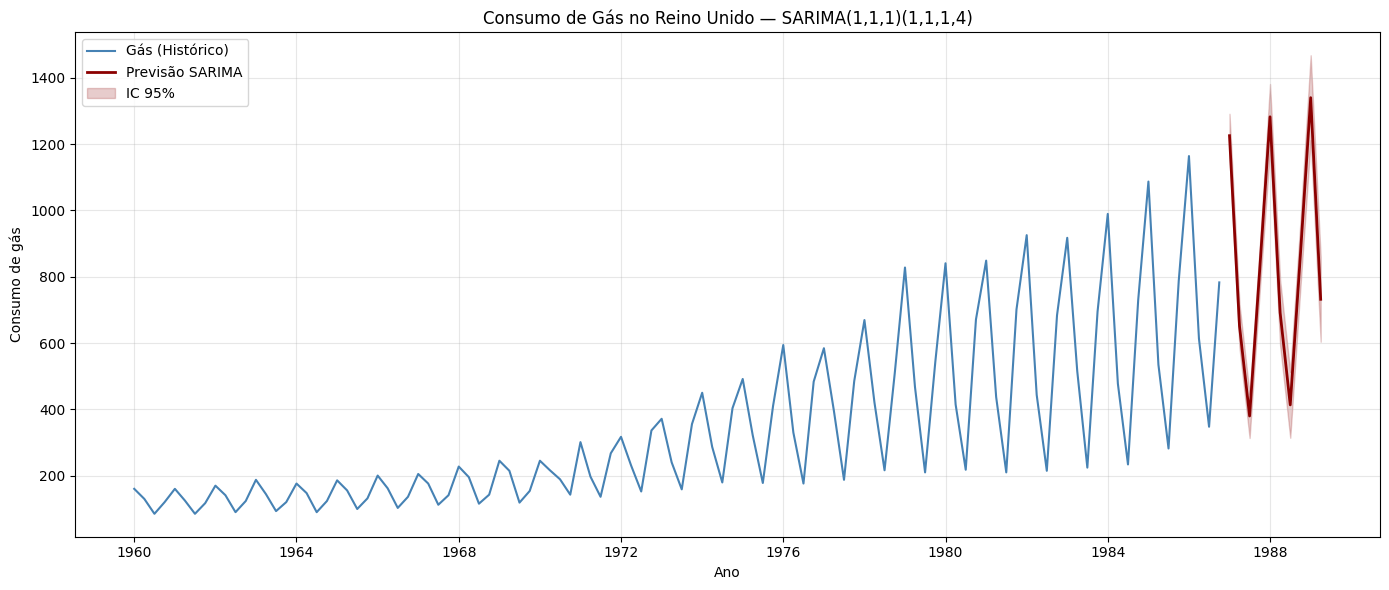

In [9]:
# Gráfico
plt.figure(figsize=(14, 6))
plt.plot(serie_gas, label='Gás (Histórico)', color='steelblue')
plt.plot(previsao_sarima['mean'], color='darkred',
         label='Previsão SARIMA', linewidth=2)
plt.fill_between(
    previsao_sarima.index,
    previsao_sarima['mean_ci_lower'],
    previsao_sarima['mean_ci_upper'],
    color='darkred', alpha=0.2, label='IC 95%'
)
plt.title('Consumo de Gás no Reino Unido — SARIMA(1,1,1)(1,1,1,4)')
plt.xlabel('Ano')
plt.ylabel('Consumo de gás')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#  **Atividade 1  - Modelo SARIMA**

##  **(Item 1)** Plot a decomposição da série




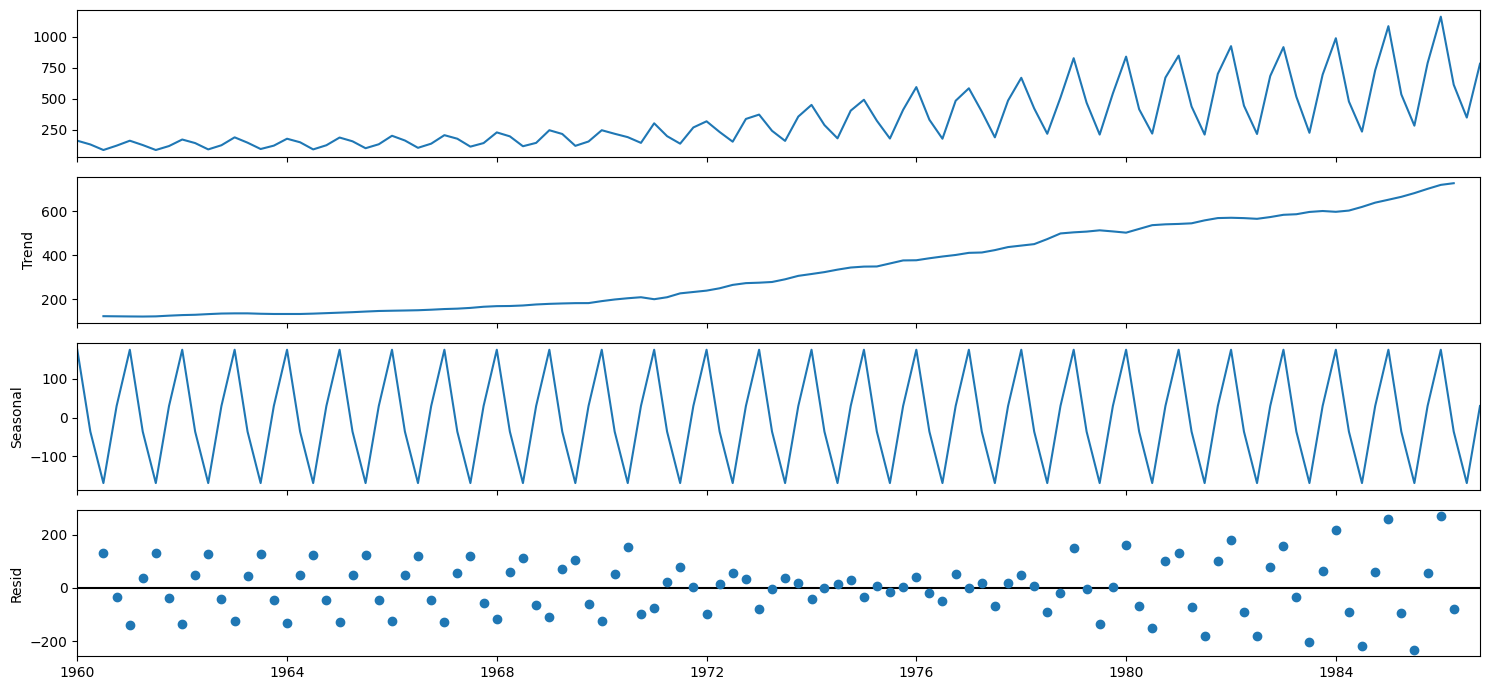

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposicao = seasonal_decompose(
    serie_gas,
    model='additive',
    period=4
)

decomposicao.plot()

plt.tight_layout()
plt.show()


## **(Item 2)** Realize a análise de estacionaridade da série.

### **Teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin)**

O teste **KPSS (Kwiatkowski-Phillips-Schmidt-Shin)** é um teste estatístico utilizado em séries temporais para verificar se os dados são estacionários em torno de uma média ou de uma tendência determinística.

**Como o Teste Funciona**

* **Hipótese Nula (H₀):** A série temporal é estacionária (em nível ou em tendência).
* **Hipótese Alternativa (H₁):** A série temporal não é estacionária (possui raiz unitária

Interpretação dos Resultados

* **p-valor > 0,05** (ou estatística menor que o valor crítico): Você não rejeita a hipótese nula. Os dados indicam que a série é estacionária.
* **p-valor ≤ 0,05** (ou estatística maior que o valor crítico): Você rejeita a hipótese nula. Há fortes evidências de que a série não é estacionár

In [11]:
import statsmodels.tsa.stattools

result_kpss = statsmodels.tsa.stattools.kpss(
    serie_gas
)

print(
    'Estatistica de teste = %.3f, p-valor = %.3f'
    % (result_kpss[0], result_kpss[1])
)


Estatistica de teste = 2.117, p-valor = 0.010


/tmp/ipykernel_1854/1607675318.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  result_kpss = statsmodels.tsa.stattools.kpss(
/tmp/ipykernel_1854/1607675318.py:3: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_kpss = statsmodels.tsa.stattools.kpss(


In [12]:
print(f"[KPSS] Estatística: {result_kpss[0]:.4f} | p-valor: {result_kpss[1]:.4f} -> " +
          ("Não-Estacionária (Rejeita H0)" if result_kpss[1] < 0.05 else "Estacionária (Falha em rejeitar H0)"))

[KPSS] Estatística: 2.1171 | p-valor: 0.0100 -> Não-Estacionária (Rejeita H0)


###  **Teste de Dickey-Fuller Aumentado (ADF)**

O Teste de Dickey-Fuller Aumentado (ADF - Augmented Dickey-Fuller) é um teste de hipótese estatística utilizado para determinar se uma série temporal é estacionária ou se possui uma raiz unitária (não estacionária).

Ele é fundamental em modelagens de séries temporais (como ARIMA, SARIMAX ou VAR), pois a maioria dos modelos estatísticos assume que a série varia em torno de uma média e variância constantes ao longo do tempo.


**Hipóteses do Teste**

O teste estrutura a tomada de decisão através de duas hipóteses:

* **Hipótese Nula ($H_0$):** A série possui raiz unitária ($\gamma = 0$).Significado: A série não é estacionária (possui tendência ou estrutura dependente do tempo).
* **Hipótese Alternativa ($H_1$):** A série não possui raiz unitária ($\gamma < 0$).Significado: A série é estacionária

Interpretação dos Resultados

* **Se $p-value \le 0,05$**  Rejeita-se a hipótese nula ($H_0$). A série é estacionária.
* **Se $p-value > 0,05$:** Não se rejeita a hipótese nula ($H_0$). A série não é estacionária e precisa de diferenciação.

In [13]:
from statsmodels.tsa.stattools import adfuller

result_adfuller = adfuller(
    serie_gas,
    autolag='AIC'
)


/tmp/ipykernel_1854/245665673.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_adfuller = adfuller(


In [14]:
print(f"[ADF]  Estatística: {result_adfuller[0]:.4f} | p-valor: {result_adfuller[1]:.4f} -> " +
          ("Estacionária (Rejeita H0)" if result_adfuller[1] < 0.05 else "Não-Estacionária (Falha em rejeitar H0)")),

[ADF]  Estatística: 3.4925 | p-valor: 1.0000 -> Não-Estacionária (Falha em rejeitar H0)


(None,)

## **(Item 3)** Realizar análise ACF e PACF


In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

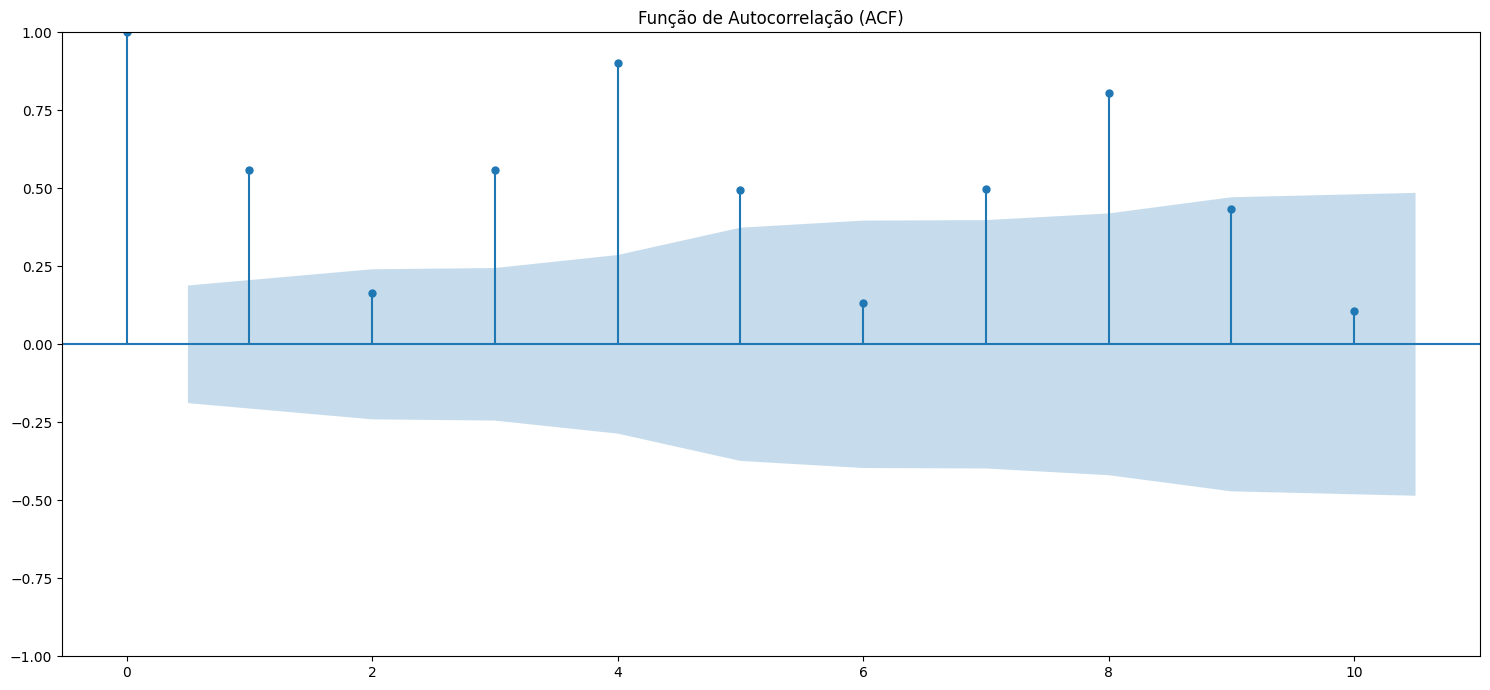

In [16]:
plot_acf(
    serie_gas,
    lags=10,
    color='#1f77b4',
    title='Função de Autocorrelação (ACF)'
)

plt.tight_layout()
plt.show()


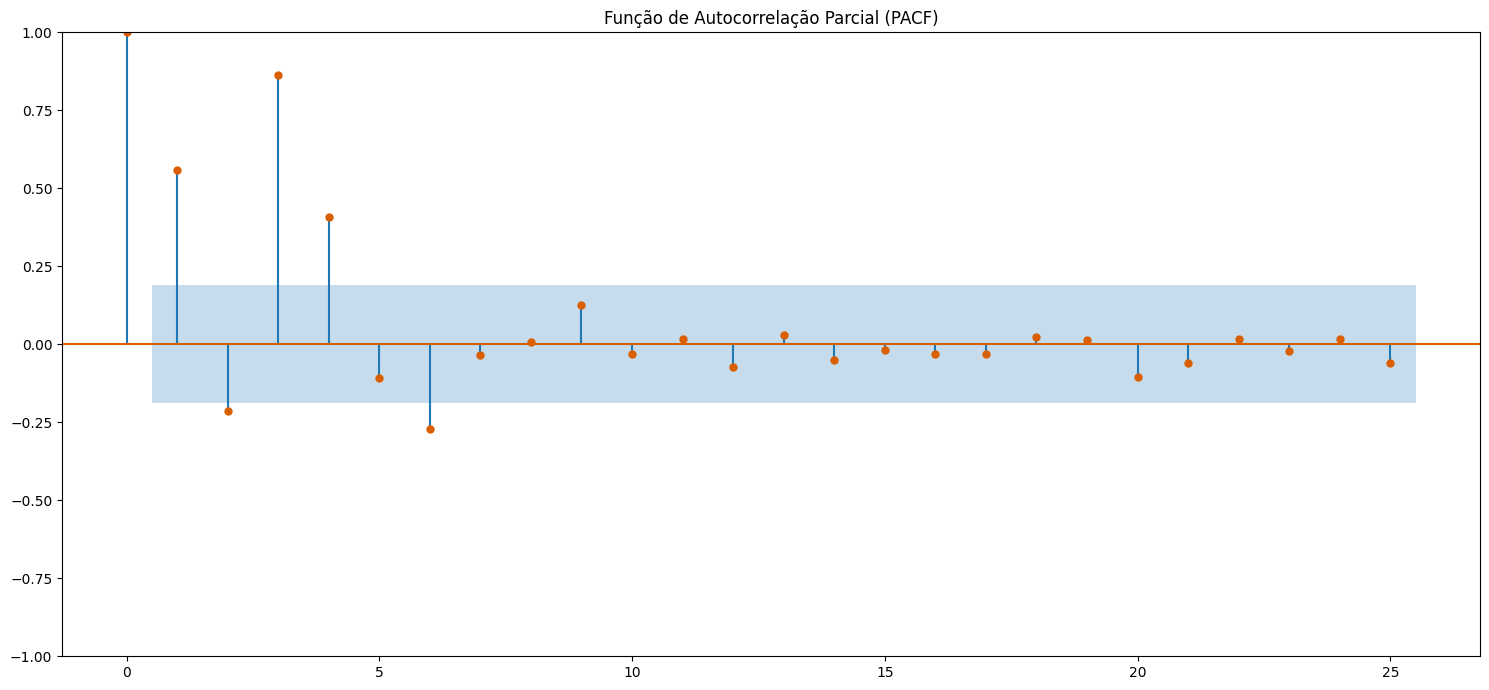

In [17]:
plot_pacf(
    serie_gas,
    lags=25,
    color='#d95f02',
    title='Função de Autocorrelação Parcial (PACF)'
)

plt.tight_layout()
plt.show()


## **Defina o modelo SARIMA**

In [18]:
# Modelo SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
# s=4 porque os dados são trimestrais (4 trimestres por ano)
modelo_sarima = SARIMAX(
    serie_gas,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 4)
)

In [19]:
modelo_sarima_result = modelo_sarima.fit()

print("Modelo SARIMA ajustado com sucesso.")


Modelo SARIMA ajustado com sucesso.


In [20]:
modelo_sarima_result.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  108
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 4)   Log Likelihood                -510.341
Date:                           Mon, 21 Sep 2026   AIC                           1030.681
Time:                                   00:27:56   BIC                           1043.855
Sample:                               01-01-1960   HQIC                          1036.017
                                    - 10-01-1986                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1129      0.095     -1.193      0.233      -0.298       0.073
ma.L1         -0.9395      0.043    -21.730      0.000      -1.024      -0.855
ar.S.L4        0.9832      0.096     10.279      0.000       0.796       1.171
ma.S.L4       -0.9318      0.197     -4.735      0.000      -1.318      -0.546
sigma2      1134.8737    144.354      7.862      0.000     851.945    1417.803
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):                17.22
Prob(Q):                              0.72   Prob(JB):                         0.00
Heteroskedasticity (H):              34.08   Skew:                             0.47
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

##**(Item 4)** Realize o estudo dos residuos da série
* Verifique a Normalidade da série por meio do teste de Shapiro-Wilk
* Verifique a estacionaridade da série por meio dos teste KPSS e ADF
* Plot  o gráfico da série e resíduos sobrepostos

In [21]:
residuos_sarima = modelo_sarima_result.resid


In [22]:
from scipy.stats import shapiro

resultado_shapiro = shapiro(residuos_sarima)

print(
    f"[Shapiro-Wilk] Estatística: {resultado_shapiro.statistic:.4f} | "
    f"p-valor: {resultado_shapiro.pvalue:.4f}"
)

if resultado_shapiro.pvalue < 0.05:
    print("Interpretação: rejeita-se H0; os resíduos não apresentam evidência suficiente de normalidade.")
else:
    print("Interpretação: não se rejeita H0; os resíduos são compatíveis com normalidade ao nível de 5%.")


[Shapiro-Wilk] Estatística: 0.9351 | p-valor: 0.0001
Interpretação: rejeita-se H0; os resíduos não apresentam evidência suficiente de normalidade.


In [23]:
result_kpss_residuos = statsmodels.tsa.stattools.kpss(
    residuos_sarima
)

print(
    f"[KPSS Resíduos] Estatística: {result_kpss_residuos[0]:.4f} | "
    f"p-valor: {result_kpss_residuos[1]:.4f}"
)

if result_kpss_residuos[1] < 0.05:
    print("Interpretação: rejeita-se H0; os resíduos apresentam evidência de não-estacionariedade.")
else:
    print("Interpretação: não se rejeita H0; os resíduos são compatíveis com estacionariedade ao nível de 5%.")


[KPSS Resíduos] Estatística: 0.1032 | p-valor: 0.1000
Interpretação: não se rejeita H0; os resíduos são compatíveis com estacionariedade ao nível de 5%.


/tmp/ipykernel_1854/1490200480.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  result_kpss_residuos = statsmodels.tsa.stattools.kpss(
/tmp/ipykernel_1854/1490200480.py:1: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_kpss_residuos = statsmodels.tsa.stattools.kpss(


In [24]:
result_adf_residuos = adfuller(
    residuos_sarima,
    autolag='AIC'
)

print(
    f"[ADF Resíduos] Estatística: {result_adf_residuos[0]:.4f} | "
    f"p-valor: {result_adf_residuos[1]:.4f}"
)

if result_adf_residuos[1] < 0.05:
    print("Interpretação: rejeita-se H0; os resíduos são compatíveis com estacionariedade.")
else:
    print("Interpretação: não se rejeita H0; os resíduos apresentam evidência de não-estacionariedade.")


[ADF Resíduos] Estatística: -11.9358 | p-valor: 0.0000
Interpretação: rejeita-se H0; os resíduos são compatíveis com estacionariedade.


/tmp/ipykernel_1854/3689841838.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_adf_residuos = adfuller(


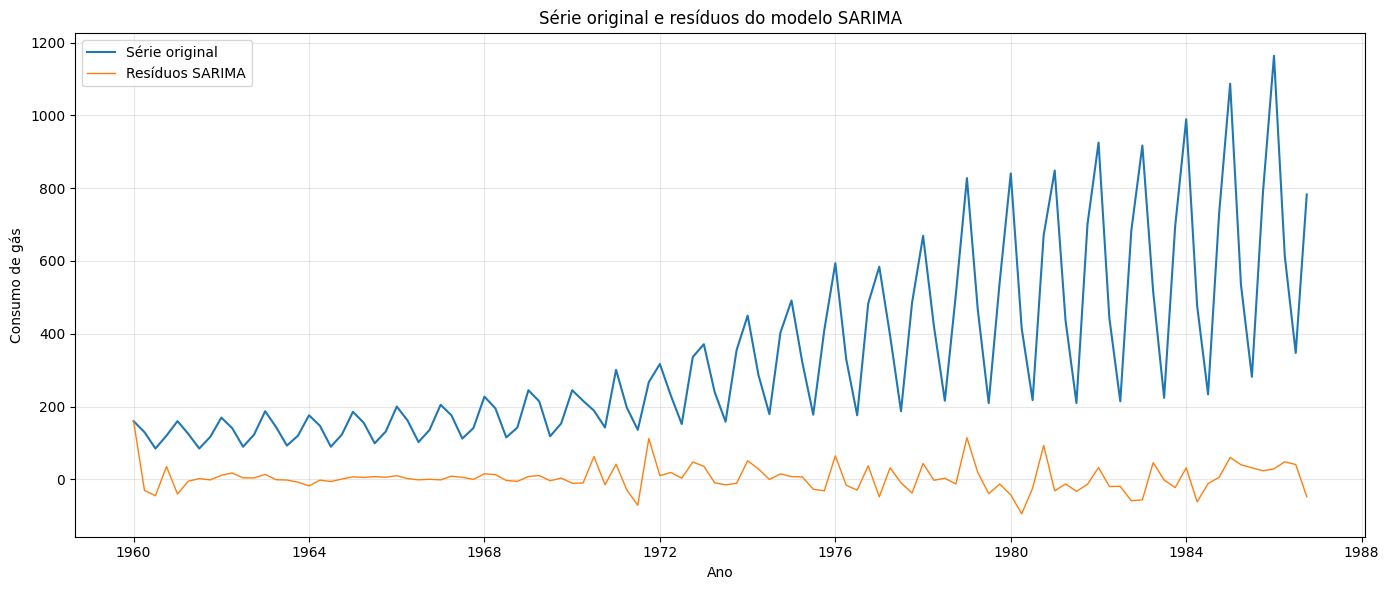

In [25]:
plt.figure(figsize=(14, 6))

plt.plot(
    serie_gas,
    label='Série original',
    linewidth=1.5
)

plt.plot(
    residuos_sarima,
    label='Resíduos SARIMA',
    linewidth=1
)

plt.title('Série original e resíduos do modelo SARIMA')
plt.xlabel('Ano')
plt.ylabel('Consumo de gás')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## **(Item 5)** Realize a previsão dos proximos 10 termos para a série temporal e o intervaloconfiaça da previsão.

In [26]:
previsao_sarima = modelo_sarima_result.get_forecast(
    steps=10
).summary_frame()

previsao_sarima


y,mean,mean_se,mean_ci_lower,mean_ci_upper
1987-01-01,1225.325977,33.722923,1159.230263,1291.421691
1987-04-01,651.231426,33.766714,585.049883,717.412969
1987-07-01,379.792136,33.841078,313.464843,446.119430
1987-10-01,825.247264,33.887697,758.828598,891.665930
1988-01-01,1282.305966,50.438779,1183.447777,1381.164156
1988-04-01,691.017911,50.435018,592.167093,789.868729
1988-07-01,413.291212,50.609014,314.099366,512.483057
1988-10-01,868.705310,50.743631,769.249621,968.160999
1989-01-01,1340.044391,65.276130,1212.105528,1467.983255
1989-04-01,731.852590,65.296127,603.874533,859.830648


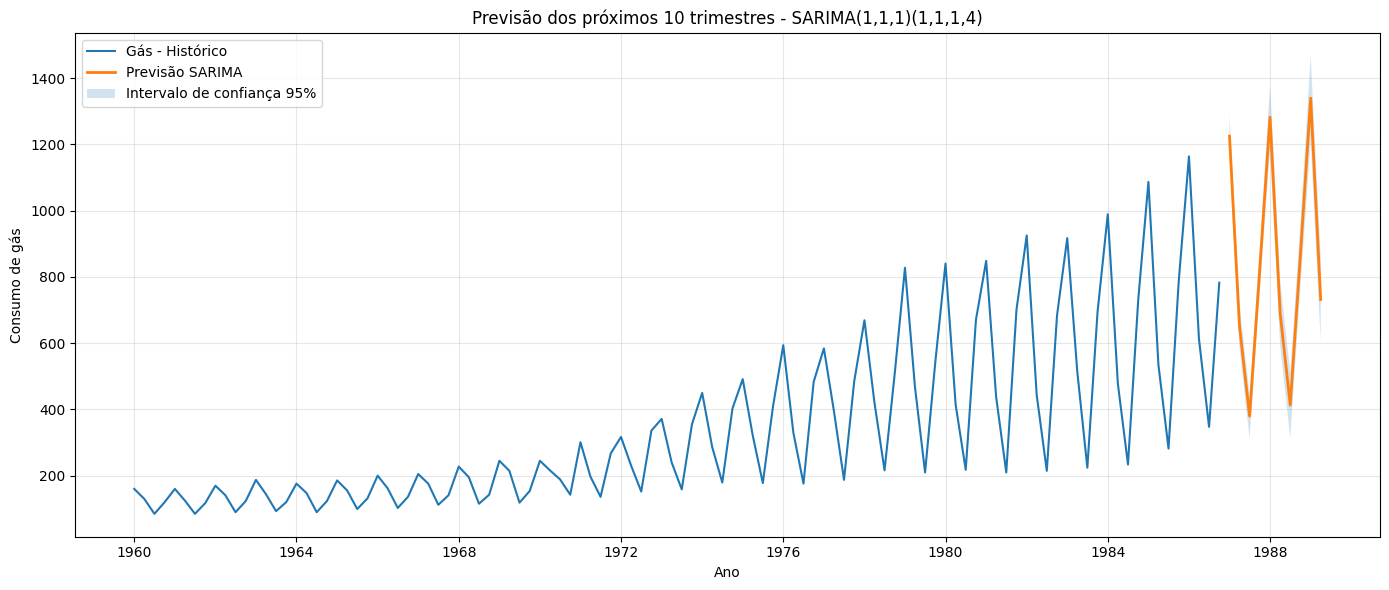

In [27]:
plt.figure(figsize=(14, 6))

plt.plot(
    serie_gas,
    label='Gás - Histórico'
)

plt.plot(
    previsao_sarima['mean'],
    label='Previsão SARIMA',
    linewidth=2
)

plt.fill_between(
    previsao_sarima.index,
    previsao_sarima['mean_ci_lower'],
    previsao_sarima['mean_ci_upper'],
    alpha=0.2,
    label='Intervalo de confiança 95%'
)

plt.title(
    'Previsão dos próximos 10 trimestres - SARIMA(1,1,1)(1,1,1,4)'
)

plt.xlabel('Ano')
plt.ylabel('Consumo de gás')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### **Conclusão da atividade**

O modelo utilizado foi o **SARIMA(1,1,1)(1,1,1,4)**, adequado ao contexto trimestral do dataset UKgas. Foram realizados: decomposição da série, testes ADF e KPSS, análise ACF/PACF, ajuste do modelo, análise dos resíduos por Shapiro-Wilk/ADF/KPSS e previsão dos próximos 10 períodos com intervalo de confiança de 95%.

> **Observação:** os valores numéricos e as conclusões estatísticas devem ser obtidos pela execução das células deste notebook.


Veja o passo a passo na **Etapas de para treinar os modelos**